# Investigation Metiers du numérique

## Clean data

In [17]:
import csv
import pandas as pd

input_file = "data/Arborescence-4A-CDC-frama.csv"
output_file = "Arborescence-4A-CDC_corrige.csv"

# --- Nettoyage robuste ---
with open(input_file, "r", encoding="utf-8", newline="") as infile, \
     open(output_file, "w", encoding="utf-8", newline="") as outfile:
    
    reader = csv.reader(infile)
    writer = csv.writer(outfile)
    
    for row in reader:
        cleaned_row = []
        for cell in row:
            # Supprimer les retours à la ligne internes
            cleaned_cell = cell.replace("\n", " ").replace("\r", " ")
            cleaned_row.append(cleaned_cell.strip())
        
        writer.writerow(cleaned_row)

print("✅ Fichier nettoyé :", output_file)

# --- Chargement dans pandas ---
df = pd.read_csv(output_file)

print("✅ Fichier chargé correctement")
print(df)

✅ Fichier nettoyé : Arborescence-4A-CDC_corrige.csv
✅ Fichier chargé correctement
            id        Domaine Categorie      Sections        Pages-main  \
0      I.1.1.1  Présentations         🧐  Mon Histoire      Prise d’élan   
1      I.1.1.2  Présentations         🧐  Mon Histoire         Décollage   
2      I.1.1.3  Présentations         🧐  Mon Histoire  Le Mythe d’Icare   
3      I.1.1.4  Présentations         🧐  Mon Histoire     et du Phoenix   
4    I.1.2.1.1  Présentations         🧐  Mes Opinions         Numérique   
..         ...            ...       ...           ...               ...   
211     VI.3.4      Marketing         💑         Suivi               NaN   
212     VI.4.1      Marketing         📨     Stratégie               NaN   
213     VI.4.2      Marketing         📨      Création               NaN   
214     VI.4.3      Marketing         📨       Gestion               NaN   
215     VI.4.4      Marketing         📨         Suivi               NaN   

    Sous-pages Ho

## Plot Data

          id        Domaine Categorie      Sections        Pages-main  \
0    I.1.1.1  Présentations         🧐  Mon Histoire      Prise d’élan   
1    I.1.1.2  Présentations         🧐  Mon Histoire         Décollage   
2    I.1.1.3  Présentations         🧐  Mon Histoire  Le Mythe d’Icare   
3    I.1.1.4  Présentations         🧐  Mon Histoire     et du Phoenix   
4  I.1.2.1.1  Présentations         🧐  Mes Opinions         Numérique   

  Sous-pages Hook  
0        NaN  NaN  
1        NaN  NaN  
2        NaN  NaN  
3        NaN  NaN  
4    Métiers  NaN  
Index(['id', 'Domaine', 'Categorie', 'Sections', 'Pages-main', 'Sous-pages',
       'Hook'],
      dtype='object')


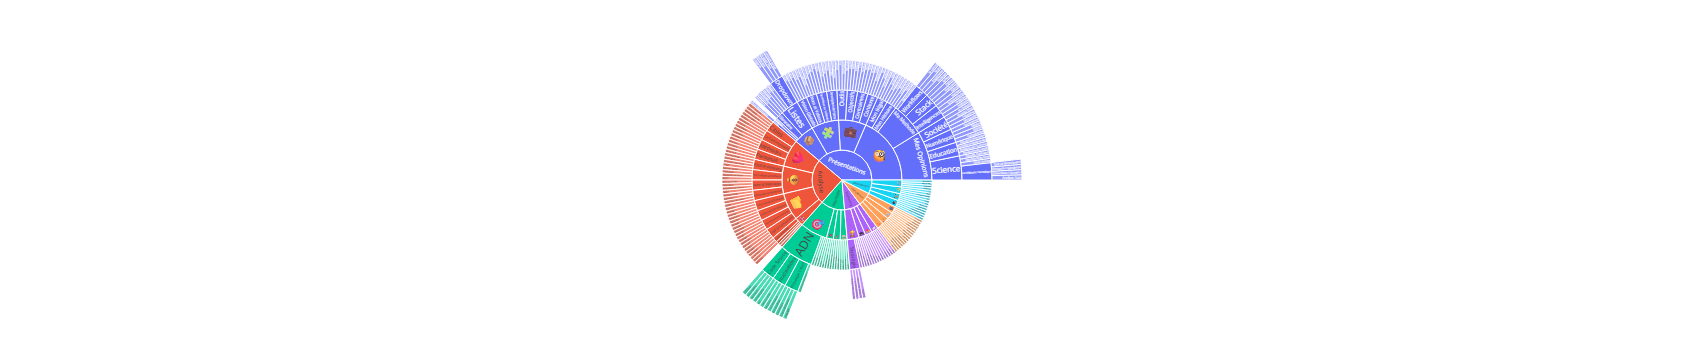

In [20]:
import pandas as pd
import plotly.express as px

# Charger le fichier CSV (⚠️ séparateur ;)
df = pd.read_csv(
    "Arborescence-4A-CDC_corrige.csv",
    sep=",",
    encoding="utf-8-sig"
)

# Vérification
print(df.head())
print(df.columns)

# Création du Sunburst
fig = px.sunburst(
    df,
    path=["Domaine", "Categorie", "Sections", "Pages-main", "Sous-pages", "Hook"],
)

fig.update_layout(margin=dict(t=0, l=0, r=0, b=0))

fig.show()

In [22]:
import pandas as pd
import plotly.express as px

# Charger le fichier CSV
df = pd.read_csv(
    "Arborescence-4A-CDC_corrige.csv",
    sep=",",
    encoding="utf-8-sig"
)

# Ajouter une colonne de comptage
df["count"] = 1

# Création du Sunburst
fig = px.sunburst(
    df,
    path=["Domaine", "Categorie", "Sections", "Pages-main", "Sous-pages", "Hook"],
    values="count",
    title=""
)

# 🔥 IMPORTANT
fig.update_traces(
    sort=False,              # respecte l'ordre du dataframe
    rotation=90   # sens horaire
)

fig.update_layout(
    margin=dict(t=0, l=0, r=0, b=0)
)

# Export en HTML autonome
fig.write_html(
    "output/Arborescence-site.html",
    full_html=True,
    include_plotlyjs="cdn"  # plus léger (charge Plotly via CDN)
)

print("Fichier exporté : arborescence-site.html")

Fichier exporté : arborescence-site.html
